In [1]:
## Libraries needs to run the scripts ##
from   MLMicelle.utils import traj_reader as trj
import MLMicelle.clustering as clst
import MLMicelle.analysis as mic_anal
import MLMicelle.visualization as plts
import pandas as pd
import numpy as np
import MDAnalysis as mda

In [2]:
#path for topology files & trajectory#
traj_dir = './'

## upload traj files using mda##
traj_files = [traj_dir + '/equil9-pbc.xtc',
              traj_dir + '/equil10-pbc.xtc',
              traj_dir +'/equil11-pbc.xtc' ]
## load the trajectory file using MDAnalysis
u = mda.Universe(traj_dir + '/equil9.tpr', traj_files, in_memory=True, in_memory_step=50)

## Process the Trajectory Information to a pd.DataFrame
init_clustered_data = clst.clustering(u, bead_type='PO')

# Remove the solvent molecules
clustered_data = init_clustered_data[init_clustered_data['residue_name'] == 'LIG']

# Generating three index files, one for PO beads, one for all beads, and one for molecule numbers
clst.index_gen(clustered_data, PO_bead='PO', index_names='./clustered')

# Analyzing the clustered data to get micelle size, core size, aggregation number, and anisotropy
mice_size, core_size, agg_numb, anisotropy =  mic_anal.analysis(u, clustered_data)

# # Printing the Results
print('anisotropy:', anisotropy)
print('agg_numb:', agg_numb)

anisotropy: [np.float64(0.003782898006576163), np.float64(0.010719852011077613), np.float64(0.0867423199727505)]
agg_numb: [60, 17, 2]


In [5]:
# Analyzing the clustered data to get micelle size, core size, aggregation number, and anisotropy
mice_size, core_size, agg_numb, anisotropy =  mic_anal.analysis(u, clustered_data)

# # Printing the Results
print('anisotropy:', anisotropy)

anisotropy: [np.float64(0.003782898006576163), np.float64(0.010719852011077613), np.float64(0.0867423199727505)]


In [3]:
# importing Statistics module 
import statistics 

## creating the data sets ##
sample = [60, 17]

## Calculating SD of the data ##
print("SD of sample %s" % (statistics.stdev(sample)))

## Calculating mean ##
print ("Mean Value of Sample %s" % (statistics.mean(sample)))

SD of sample 30.405591591021544
Mean Value of Sample 38.5


In [22]:
clustered_data

,residue_number,residue_name,atom_name,atom_number,x,y,z,clusters
0,1,LIG,EO,0,1.463000,6.847000,5.669000,0.0
1,1,LIG,EO,1,1.638000,6.952001,5.445000,0.0
2,1,LIG,EO,2,1.757000,6.888000,5.154000,0.0
3,1,LIG,EO,3,1.620000,6.666000,5.001000,0.0
4,1,LIG,EO,4,1.429000,6.784000,4.749000,0.0
...,...,...,...,...,...,...,...,...
63535,18414,NC,CZA,63535,8.056001,3.125000,4.572000,NaN
63536,18414,NC,CZA,63536,7.705000,3.197000,4.447000,NaN
63537,18415,NC,N3A,63537,11.715000,13.181002,13.987001,NaN
63538,18415,NC,CZA,63538,11.670001,13.363001,14.033002,NaN


In [6]:
df = pd.DataFrame({'Index': range(len(anisotropy)), 'Anisotropy': anisotropy})
df.to_csv('anisotropy_output.csv', index=False)

In [4]:
!which MLMicelle

In [ ]:
mice_size, core_size, agg_numb, anisotropy = mic_anal.analysis(u, clustered_data)

In [ ]:
print(anisotropy[:5])

In [ ]:
df = pd.DataFrame({'Index': range(len(anisotropy)), 'Anisotropy': anisotropy})
df.to_csv('anisotropy_output.csv', index=False)

In [7]:
# Generating three index files, one for PO beads, one for all beads, and one for molecule numbers
clst.index_gen(clustered_data, PO_bead='PO', index_names='./clustered')

In [2]:
## Final plot for N_agg for Pluronic system ##
## Libraries needs to run the script ##
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from pylab import rc
from pathlib import Path

In [3]:
## read data files using pandas ##
data = pd.read_csv("all-anisotro.dat",names=["Conc", "K21", "K22"], sep=r'\s+', skiprows=1)
data1 = pd.read_csv("all-N-agg.dat",names=["Conc", "N1", "N2"], sep=r'\s+', skiprows=1)

In [4]:
data1

,Conc,N1,N2
0,20,60,65
1,40,151,156
2,60,236,234


In [5]:
df = pd.DataFrame(data)

# Compute the mean of K21 and K22 row-wise
df['K_mean'] = df[['K21', 'K22']].mean(axis=1)

# Display the updated DataFrame
print(df['K_mean'])

df['K_std'] = df[['K21', 'K22']].std(axis=1)

# Display the updated DataFrame
print(df)

0    0.003891
1    0.214591
2    0.422398
Name: K_mean, dtype: float64
   Conc       K21       K22    K_mean     K_std
0    20  0.003782  0.004000  0.003891  0.000154
1    40  0.148444  0.280739  0.214591  0.093547
2    60  0.425876  0.418920  0.422398  0.004919


In [6]:
df1 = pd.DataFrame(data1)

# Compute the mean of K21 and K22 row-wise
df1['N_mean'] = df1[['N1', 'N2']].mean(axis=1)

# Display the updated DataFrame
print(df1['N_mean'])

df1['N_std'] = df1[['N1', 'N2']].std(axis=1)

# Display the updated DataFrame
print(df1)

0     62.5
1    153.5
2    235.0
Name: N_mean, dtype: float64
   Conc   N1   N2  N_mean     N_std
0    20   60   65    62.5  3.535534
1    40  151  156   153.5  3.535534
2    60  236  234   235.0  1.414214


In [7]:
df['K_std']

0    0.000154
1    0.093547
2    0.004919
Name: K_std, dtype: float64

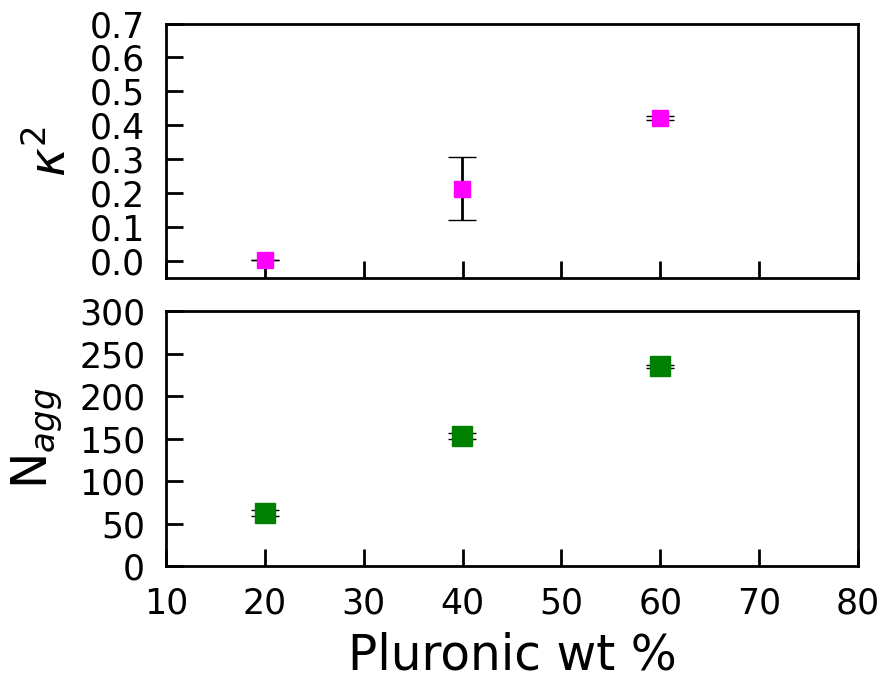

In [24]:
# Set global axis line width
from pylab import*
rc('axes', linewidth=2.0)
Pluronic = df['Conc']
STD = df['K_std']
Value = df['K_mean']
N_Value = df1['N_mean']
STD1 = df1['N_std']
# Create subplots: 1 row, 2 columns
fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# First plot
##axs[0].plot(data["Conc"],data["K2"],color='magenta',  marker='s', linestyle='None', linewidth=2, markersize=15)
##axs[0].plot(Pluronic,Value,color='magenta',  marker='s', linestyle='None', linewidth=2, markersize=15)
axs[0].errorbar(Pluronic, Value, yerr=STD, color='magenta', marker='s', linestyle='None', linewidth=2, markersize=12,capsize=10,ecolor='black')
axs[0].set_xlim([10.01, 80.01])
axs[0].set_ylim([-0.05, 0.7])
axs[0].set_yticks(np.arange(0.0, 0.701, 0.1))
#axs[0].set_title('A', fontsize=18, fontname='serif', loc='left')
#axs[0].legend(fontsize=18, bbox_to_anchor=(0.99, 0.998), loc='upper right', edgecolor='white')
axs[0].set_ylabel(r'$\kappa^2$', fontsize=35, fontname='DejaVu Sans', labelpad=10)
#axs[0].set_xlabel('Pluronic wt %', fontsize=30, fontname='DejaVu Sans', labelpad=8)


# Second plot
##axs[1].plot(data1["Conc"],data1["N_agg"],color='green',  marker='s', linestyle='None', linewidth=2, markersize=15)
axs[1].errorbar(Pluronic, N_Value, yerr=STD1, color='green', marker='s', linestyle='None', linewidth=2, markersize=15,capsize=10,ecolor='black')
axs[1].set_xlim([10.01, 80.01])
axs[1].set_ylim([0, 300])
axs[1].set_yticks(np.arange(0, 300.01, 50))
#axs[0].set_title('A', fontsize=18, fontname='DejaVu Sans', loc='left')
##axs[1].legend(fontsize=18, bbox_to_anchor=(0.99, 0.998), loc='upper right', edgecolor='white')
axs[1].set_ylabel(r'N$_{agg}$', fontsize=35, fontname='DejaVu Sans', labelpad=10)
axs[1].set_xlabel('Pluronic wt %', fontsize=35, fontname='DejaVu Sans', labelpad=8)

# Ticks & fonts
for ax in axs:
    ax.set_xticks(np.arange(10.01, 80.05, 10))
    #ax.set_yticks(np.arange(-520000.01, -60000.05, 80000))
    ax.tick_params(axis='both', which='major', length=12, direction='in', width=2, labelsize=25, pad=15)
    #ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    #ax.ticklabel_format(style='sci', axis='y', scilimits=(5,5))

## Customize the offset text ##
    #offset_text = ax.yaxis.get_offset_text()
   # offset_text.set_size(25)  # Set font size
#    offset_text.set_color('green')  # Optional: change color
#
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('DejaVu Sans')
# Layout & save
plt.tight_layout()
plt.savefig('Figure4-reviwer2.png', dpi=600,  bbox_inches='tight')
plt.show()